In [1]:
from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.ligsaf_settings import feed_parameters, prices
from lignin_saf.ligsaf_system import create_rcf_system
from lignin_saf.ligsaf_purification_system import create_rcf_oil_purification_system
from lignin_saf.monomer_purification import create_monomer_purification_system
from lignin_saf.ligsaf_utilities_system import create_rcf_utilities_system
from biorefineries import cellulosic
from cellulosic_tea import create_cellulosic_ethanol_tea
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import numpy as np
bst.nbtutorial()

In [2]:
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [3]:
chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 541.7   # 2016 USD basis

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price = prices['Feedstock'])



In [4]:
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()



In [5]:
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_Oil)


In [6]:
monomer_purification_sys = create_monomer_purification_system(ins=F.Purified_RCF_Oil)

In [7]:
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()

In [8]:
BT, WWT, gas_mixer = create_rcf_utilities_system()

In [9]:
'''
BT = bst.facilities.BoilerTurbogenerator(fuel_price = 0.2612)
WWT = bst.create_conventional_wastewater_treatment_system(
        'WWT',
        ins=(F.WW_10, 
             F.WastePulp, 
             F.RCF_WW, 
             F.WW_11, 
             F.WW_12
              ),
    )
'''

"\nBT = bst.facilities.BoilerTurbogenerator(fuel_price = 0.2612)\nWWT = bst.create_conventional_wastewater_treatment_system(\n        'WWT',\n        ins=(F.WW_10, \n             F.WastePulp, \n             F.RCF_WW, \n             F.WW_11, \n             F.WW_12\n              ),\n    )\n"

In [10]:
#BT.ins[0] = WWT.outs[1]
#gas_mixer = bst.Mixer('MIX_BT_gas', ins=(F.Purge_Light_Gases, WWT.outs[0]))
#BT.ins[1] = gas_mixer.outs[0]


In [11]:
#etoh_system = cellulosic.create_cellulosic_ethanol_system(ins = F.Carbohydrate_Pulp)
#etoh_system.simulate()

In [12]:
#for unit in WWT.units:
#    if hasattr(unit, 'strict_moisture_content'):
#        unit.strict_moisture_content = False

In [13]:
rcf_combined_system = bst.System(
    'Combined_RCF_System',
    path=(rcf_system, 
          rcf_oil_purification_sys, 
          monomer_purification_sys, 
          WWT),
    facilities=[gas_mixer, BT],
)

In [14]:
rcf_combined_system.simulate()

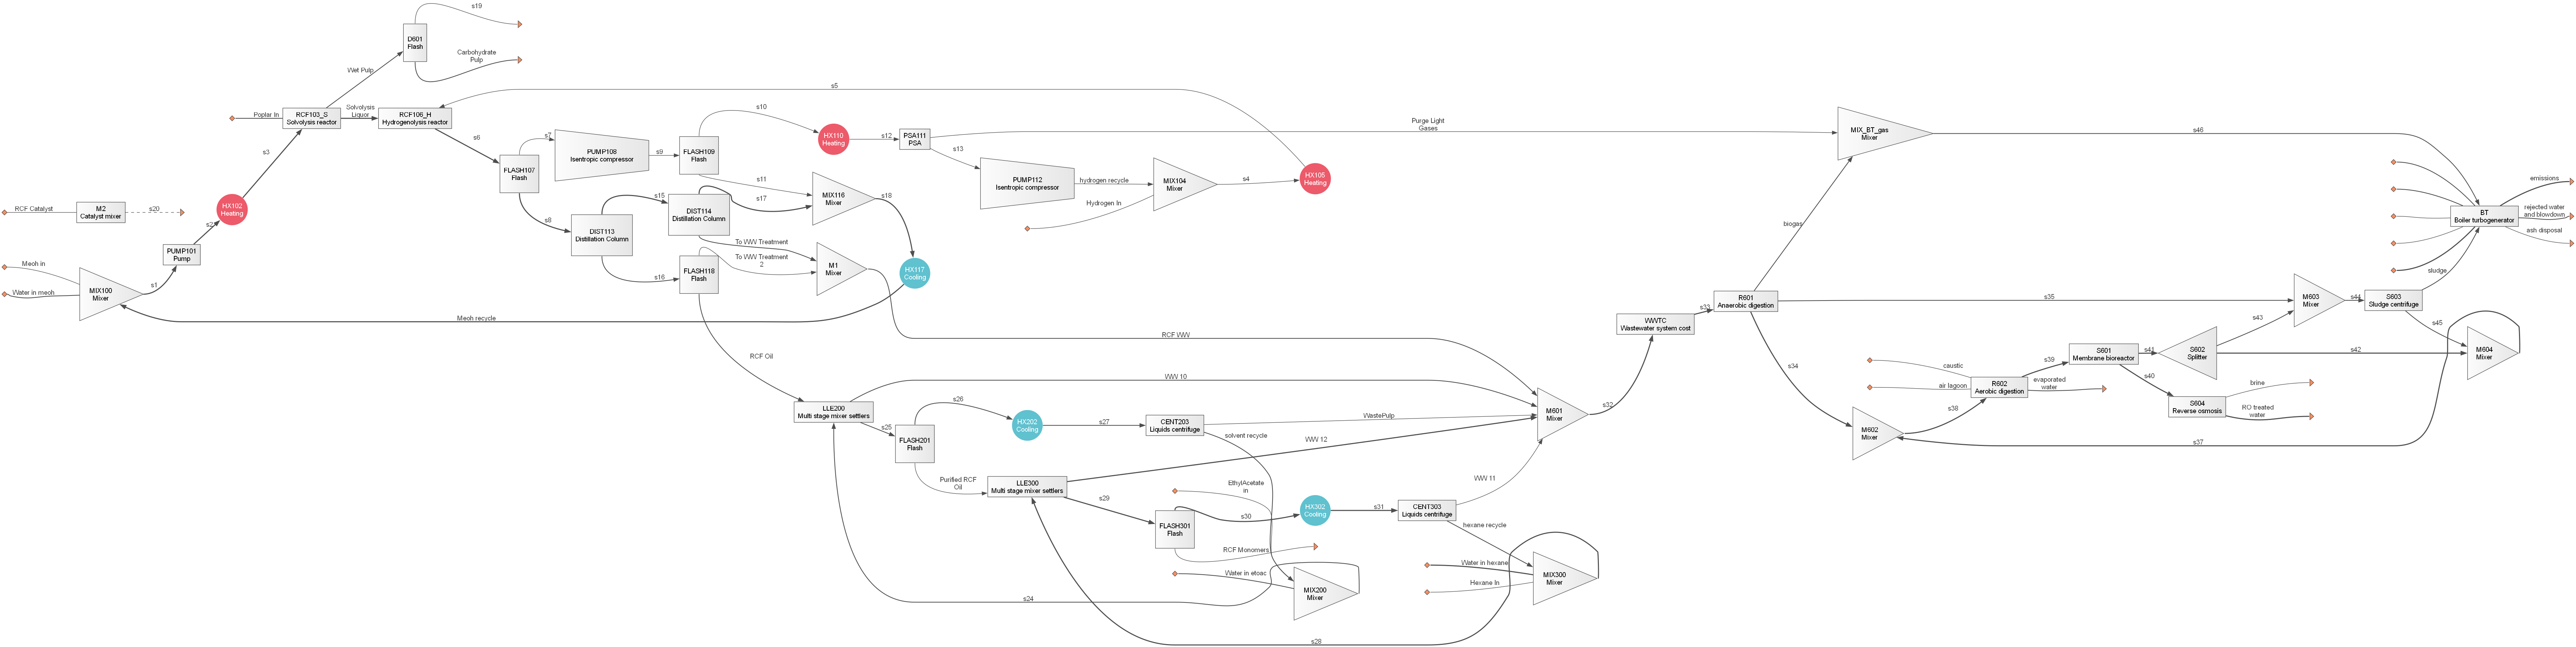

In [15]:
rcf_combined_system.diagram(format = 'png')

In [16]:
operators_per_section = 1  # operators per section from Seider recommendation
num_process_sections = 3  # number of proces sections from Seider recommendation [2 reactor, 1 separation]
num_operators_per_shift = operators_per_section * num_process_sections * 1  # multiplied by 2 for large continuous flow process (e.g., 1000 ton/day product). from Seider pg 505
num_shifts = 5  # number of shifts
pay_rate = 40  # $/hr
DWandB = num_operators_per_shift * num_shifts * 2080 * pay_rate  # direct wages and benefits. DWandB [$/year] = (operators/shift)*(5 shifts)*(40 hr/week)*(operating days/year-operator)*($/hr)
Dsalaries_benefits = 0.15 * DWandB  # direct salaries and benefits from Seider
O_supplies = 0.06 * DWandB  # Operating supplies and services from Seider
technical_assistance = 5 * 75000  # $/year. Technical assistance to manufacturing. assume 5 workers at $75000/year
control_lab = 5 * 80000  # $/year. Control laboratory. assume 5 workers at $80000/year
labor = DWandB + Dsalaries_benefits + O_supplies + technical_assistance + control_lab 

In [17]:
F.Carbohydrate_Pulp.price = prices['Feedstock']

In [18]:
F.DIST113

BinaryDistillation: DIST113
ins...
[0] s8  from  Flash-FLASH107
    phase: 'l', T: 320 K, P: 500000 Pa
    flow (kmol/hr): Water           4.19e+03
                    Extract         7.4
                    Acetate         48.6
                    SolubleLignin   0.000145
                    Glucan          23.8
                    Xylan           5.92
                    Arabinan        0.757
                    Mannan          9.51
                    Galactan        3.6
                    Methanol        1.51e+04
                    Propylguaiacol  5.24
                    Propylsyringol  4.44
                    Syringaresinol  6.58
                    G_Dimer         7.6
                    S_Oligomer      12.1
                    G_Oligomer      13.7
outs...
[0] s15  to  BinaryDistillation-DIST114
    phase: 'g', T: 346.08 K, P: 101325 Pa
    flow (kmol/hr): Water     4.05e+03
                    Methanol  1.51e+04
[1] s16  to  Flash-FLASH118
    phase: 'l', T: 369.19 K, P: 101

In [19]:
integrated_tea = create_cellulosic_ethanol_tea(rcf_combined_system)

In [20]:
integrated_tea.labor_cost = labor

In [21]:
print(f'The MSP for RCF monomers is  {round(integrated_tea.solve_price(F.RCF_Monomers),3)} USD/kg')

The MSP for RCF monomers is  27.764 USD/kg


In [22]:
print('CAPEX', round(rcf_combined_system.installed_equipment_cost / 1e6, 2), 'MMUSD')
print('OPEX', round((rcf_combined_system.material_cost + rcf_combined_system.utility_cost) / 1e6, 3), 'MMUSD/yr')



CAPEX 528.72 MMUSD
OPEX 274.891 MMUSD/yr


In [23]:
rcf_combined_system

System: Combined_RCF_System
Highest convergence error among components in recycle
streams {HX117-0, PUMP112-0} after 1 loops:
- flow rate   1.31e-10 kmol/hr (0.011%)
- temperature 1.63e-03 K (0.00052%)
ins...
[0] RCF_Catalyst  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): NiC  2.28
[1] air_lagoon  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): N2  675
                    O2  167
[2] caustic  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water  72.4
                    NaOH   32.6
[3] Poplar_In  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water     925
                    Sucrose   0.243
                    Extract   7.4
                    Acetate   48.6
                    Ash       1e+03
                    Lignin    156
                    Glucan    238
                    Xylan     84.5
                    Arabinan  1.26
                    Mannan    19
                    Galactan  7.2
[4] Meoh_in  
    phase: 'l

In [24]:
# rcf_combined_system.units

In [25]:
# Different sections

rcf_area= [F.MIX100, F.PUMP101, F.HX102, F.RCF103_S, F.MIX104, F.HX105, F.RCF106_H, F.FLASH107, F.PUMP108,
F.FLASH109, F.HX110, F.PSA111, F.PUMP112, F.DIST113, F.DIST114, F.MIX116, F.HX117, F.FLASH118, F.M1, F.D601,F.M2]

rcf_oil_purification = [F.MIX200, F.LLE200, F.FLASH201, F.HX202, F.CENT203]

monomer_purification = [F.MIX300, F.LLE300, F.FLASH301, F.HX302, F.CENT303]

BT = [BT]

WWT = [WWT]

In [26]:
rcf_area_ic = sum(u.installed_cost for u in rcf_area)
rcf_oil_purification_ic = sum(u.installed_cost for u in rcf_oil_purification)
rcf_monomer_purification_ic = sum(u.installed_cost for u in monomer_purification)
BT_installed_cost = F.BT.installed_cost
WWT_installed_cost  = F.WWTC.installed_cost
installed_costs_arr = np.array([rcf_area_ic, rcf_oil_purification_ic, rcf_monomer_purification_ic, 
                            BT_installed_cost, WWT_installed_cost])

In [27]:
np.sum(installed_costs_arr)

528719527.5225204

Font: Arial


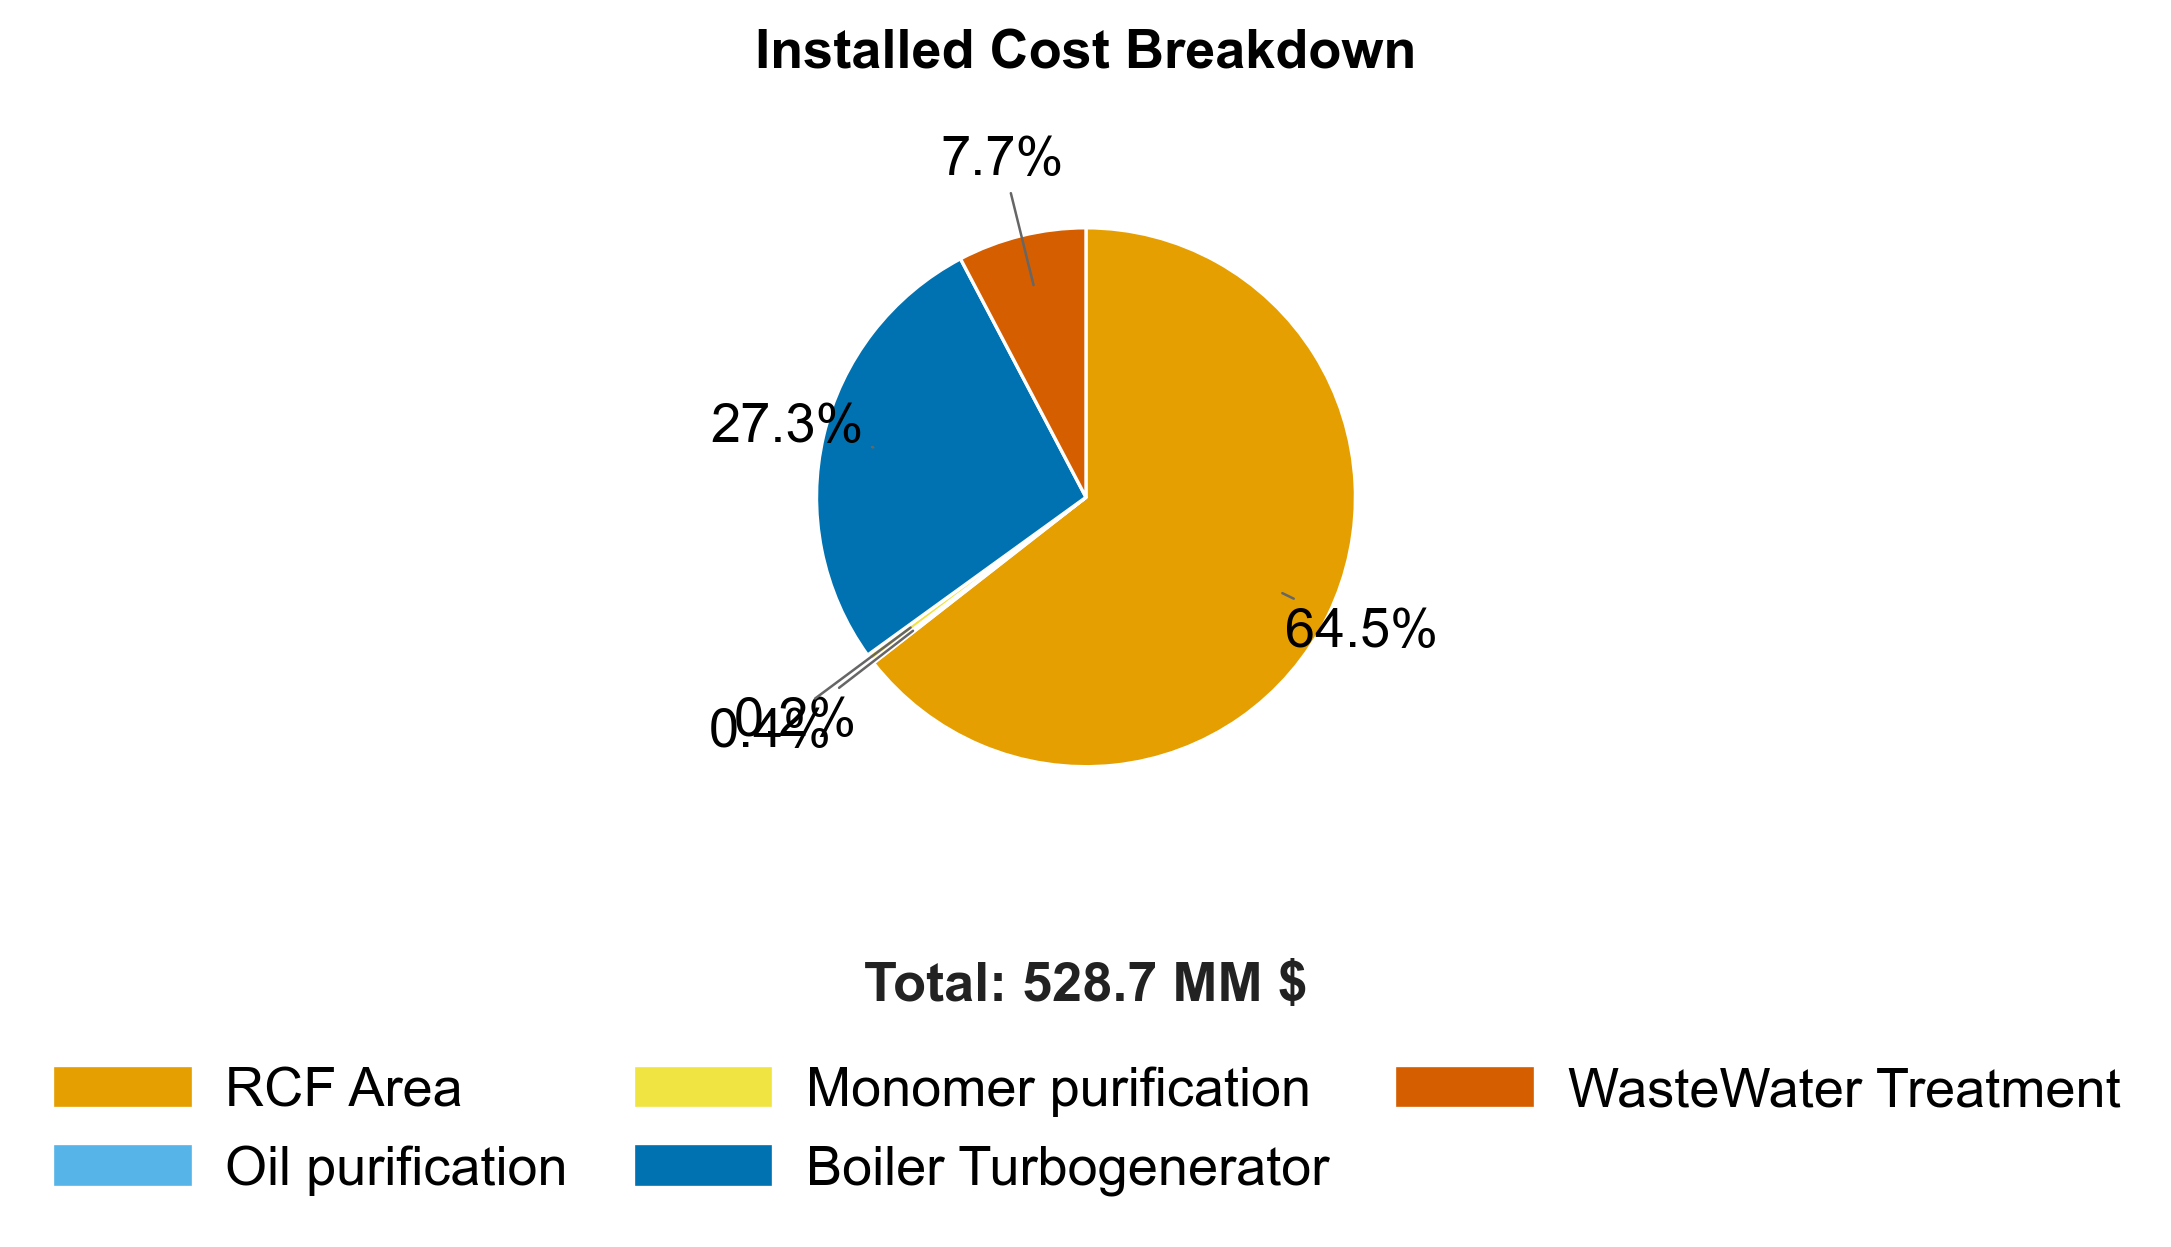

In [28]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Font ──────────────────────────────────────────────────────────────────────
font_pref = ["Arial", "Liberation Sans", "DejaVu Sans"]
available = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
chosen = next((f for f in font_pref if f in available), "DejaVu Sans")
print(f"Font: {chosen}")

plt.rcParams.update({
    "font.family": chosen,
    "mathtext.fontset": "custom",
    "mathtext.rm": chosen,
    "mathtext.it": chosen,
    "mathtext.bf": chosen,
})

plt.rcParams['svg.fonttype'] = 'none'

oi_colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]

categories = [
    "RCF Area",
    "Oil purification",
    "Monomer purification",
    "Boiler Turbogenerator",
    "WasteWater Treatment",
]

values = [
    rcf_area_ic,
    rcf_oil_purification_ic,
    rcf_monomer_purification_ic,
    BT_installed_cost,
    WWT_installed_cost,
]

# ── Figure ────────────────────────────────────────────────────────────────────
DPI      = 300
fig_w_px = 1500
fig_h_px = 1260
fig_w_in = fig_w_px / DPI
fig_h_in = fig_h_px / DPI

FS_TITLE  = 13
FS_TOTAL  = 13
FS_PCT    = 13
FS_LEGEND = 13

fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))

# ── draw_pie ──────────────────────────────────────────────────────────────────
def draw_pie(ax, vals, title):
    total = sum(vals)
    total_kt = total / 1e6
    fracs = [v / total for v in vals]

    wedges, _ = ax.pie(
        vals,
        colors=oi_colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(linewidth=0.8, edgecolor="white"),
    )

    label_data = []
    for i, (wedge, frac) in enumerate(zip(wedges, fracs)):
        pct   = frac * 100
        theta = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        if pct >= 20:   r_out = 1.14
        elif pct >= 10: r_out = 1.21
        elif pct >= 5:  r_out = 1.29
        else:           r_out = 1.38
        label_data.append(dict(theta=theta, pct=pct, r_out=r_out, r_in=0.78, idx=i))

    small_indices = [d["idx"] for d in label_data if d["pct"] < 5]
    for j, idx in enumerate(small_indices):
        label_data[idx]["r_out"] = 1.36 if j % 2 == 0 else 1.46

    for d in label_data:
        theta, r_in, r_out, pct = d["theta"], d["r_in"], d["r_out"], d["pct"]
        ax.annotate(
            f"{pct:.1f}%",
            xy=(r_in  * np.cos(theta), r_in  * np.sin(theta)),
            xytext=(r_out * np.cos(theta), r_out * np.sin(theta)),
            fontsize=FS_PCT,
            ha="center", va="center",
            arrowprops=dict(
                arrowstyle="-", color="#666666", lw=0.6,
                shrinkA=0, shrinkB=2,
            ),
        )

    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=6)
    ax.text(0, -1.72,
            r"Total: " + f"{rcf_combined_system.installed_cost/1e6:.1f}" + r" MM $",
            ha="center", va="top", fontsize=FS_TOTAL,
            color="#222222", fontweight="bold", style="normal")

    ax.set_xlim(-1.65, 1.65)
    ax.set_ylim(-1.95, 1.50)

draw_pie(ax, values, "Installed Cost Breakdown")

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=0.8, label=lbl)
    for c, lbl in zip(oi_colors, categories)
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    fontsize=FS_LEGEND,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.6,
    handleheight=0.85,
    handletextpad=0.6,
    bbox_to_anchor=(0.5, 0.0),
)

fig.tight_layout(rect=[0, 0.14, 1, 1])

#fig.savefig("ghg_pie_chart.png", dpi=DPI, bbox_inches="tight")
#fig.savefig("installed_cost_breakdown.svg", format="svg", bbox_inches="tight")
#print("Done.")